# TransferLearning

## Importing standard libraries

In [1]:
import os
import json
import time
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from tqdm.auto import tqdm


## Hyperparameter Setup

In [2]:
SEED = 42

NUM_CLASSES = 101
IMAGE_SIZE = 160

BATCH_SIZE = 64
NUM_WORKERS = 4

NUM_EPOCHS = 7

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

DATA_DIR = "/kaggle/input/food-101/food-101"
OUTPUT_DIR = "/kaggle/working/results"

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        print(
            f"GPU {i}: {torch.cuda.get_device_name(i)} | "
            f"Memory: "
            f"{torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB"
        )
else:
    print("WARNING: CUDA is not available.")


PyTorch version: 2.10.0+cu128
CUDA available: True
Number of GPUs: 2
GPU 0: Tesla T4 | Memory: 14.56 GB
GPU 1: Tesla T4 | Memory: 14.56 GB


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


## Data Transformations

In [6]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.7, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

test_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.15)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


## Loading Food-101 Dataset

In [7]:
train_dataset = datasets.Food101(
    root="/kaggle/working",
    split="train",
    transform=train_transform,
    download=True
)

test_dataset = datasets.Food101(
    root="/kaggle/working",
    split="test",
    transform=test_transform,
    download=True
)


100%|██████████| 5.00G/5.00G [02:23<00:00, 34.9MB/s] 


In [8]:
print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples:     {len(test_dataset):,}")
print(f"Classes:           {len(train_dataset.classes)}")


Training samples: 75,750
Test samples:     25,250
Classes:           101


## DataLoaders Setup

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)


In [10]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)


Images: torch.Size([64, 3, 160, 160])
Labels: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64


## ResNet-152 Model Builder (Pre-trained/From Scratch)

In [11]:
def build_resnet152(pretrained=True, train_mode="final_block"):
    """
    Build ResNet-152 for Food-101.

    Parameters
    ----------
    pretrained : bool
        If True, initialize with ImageNet-pretrained weights.
        If False, initialize randomly.

    train_mode : str
        "final_block" -> train layer4 + classifier
        "full"        -> train entire backbone + classifier
    """

    if train_mode not in ["final_block", "full"]:
        raise ValueError(
            "train_mode must be either 'final_block' or 'full'"
        )

    if pretrained:
        weights = models.ResNet152_Weights.IMAGENET1K_V2
    else:
        weights = None

    model = models.resnet152(weights=weights)

    in_features = model.fc.in_features

    model.fc = nn.Linear(
        in_features,
        NUM_CLASSES
    )

    if train_mode == "final_block":

        for param in model.parameters():
            param.requires_grad = False

        for param in model.layer4.parameters():
            param.requires_grad = True

        for param in model.fc.parameters():
            param.requires_grad = True

    elif train_mode == "full":

        for param in model.parameters():
            param.requires_grad = True

    return model


## Counting Trainable Parameters

In [12]:
def parameter_stats(model):
    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    trainable_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    frozen_params = total_params - trainable_params

    return {
        "total": total_params,
        "trainable": trainable_params,
        "frozen": frozen_params,
        "trainable_ratio": trainable_params / total_params
    }


## Model Instantiation

In [13]:
model_final = build_resnet152(
    pretrained=True,
    train_mode="final_block"
)

stats_final = parameter_stats(model_final)

print("ImageNet + Final Block")
print("-" * 40)

for key, value in stats_final.items():
    if key == "trainable_ratio":
        print(f"{key}: {value:.2%}")
    else:
        print(f"{key}: {value:,}")


Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 201MB/s]  


ImageNet + Final Block
----------------------------------------
total: 58,350,757
trainable: 15,171,685
frozen: 43,179,072
trainable_ratio: 26.00%


## Fine-Tuning (Training Full Model)

In [14]:
model_full = build_resnet152(
    pretrained=True,
    train_mode="full"
)

stats_full = parameter_stats(model_full)

print("\nImageNet + Full Backbone")
print("-" * 40)

for key, value in stats_full.items():
    if key == "trainable_ratio":
        print(f"{key}: {value:.2%}")
    else:
        print(f"{key}: {value:,}")



ImageNet + Full Backbone
----------------------------------------
total: 58,350,757
trainable: 58,350,757
frozen: 0
trainable_ratio: 100.00%


In [15]:
print("Trainable layers:")
print("=" * 50)

for name, param in model_final.named_parameters():
    if param.requires_grad:
        print(name)


Trainable layers:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


In [16]:
device = torch.device("cuda:0")

model_final = model_final.to(device)

images, labels = next(iter(train_loader))

images = images.to(device, non_blocking=True)

with torch.no_grad():
    outputs = model_final(images)

print("Input:", images.shape)
print("Output:", outputs.shape)


Input: torch.Size([64, 3, 160, 160])
Output: torch.Size([64, 101])


In [17]:
def get_amp_scaler():
    return torch.amp.GradScaler("cuda")


In [18]:
def calculate_accuracy(outputs, labels):
    predictions = outputs.argmax(dim=1)
    correct = (predictions == labels).sum().item()
    total = labels.size(0)

    return correct / total


## Training Epoch Function

In [19]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
    scaler
):
    model.train()

    freeze_batchnorm_in_frozen_layers(model)

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        running_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total_samples
    epoch_accuracy = running_correct / total_samples

    return epoch_loss, epoch_accuracy


## Model Evaluation Function

In [20]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(images)
            loss = criterion(outputs, labels)

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        running_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = running_correct / total_samples

    return epoch_loss, epoch_accuracy


## Managing BatchNorm Layers

In [21]:
def freeze_batchnorm_in_frozen_layers(model):
    """
    Keep BatchNorm layers inside frozen portions of the
    network in evaluation mode so their running statistics
    do not change during fine-tuning.
    """

    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):

            if not any(
                param.requires_grad
                for param in module.parameters()
            ):
                module.eval()

                for param in module.parameters():
                    param.requires_grad = False


## Main Training Loop

In [22]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs,
    learning_rate,
    weight_decay,
    experiment_name
):

    criterion = nn.CrossEntropyLoss()

    trainable_parameters = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    optimizer = optim.AdamW(
        trainable_parameters,
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scaler = get_amp_scaler()

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "epoch_time": []
    }

    best_val_accuracy = 0.0

    experiment_dir = os.path.join(
        OUTPUT_DIR,
        experiment_name
    )

    os.makedirs(
        experiment_dir,
        exist_ok=True
    )

    print("=" * 70)
    print(f"Experiment: {experiment_name}")
    print("=" * 70)

    stats = parameter_stats(model)

    print(
        f"Total parameters:     "
        f"{stats['total']:,}"
    )

    print(
        f"Trainable parameters: "
        f"{stats['trainable']:,}"
    )

    print(
        f"Trainable ratio:      "
        f"{stats['trainable_ratio']:.2%}"
    )

    print()

    for epoch in range(num_epochs):

        epoch_start = time.time()

        print(
            f"Epoch {epoch + 1}/{num_epochs}"
        )

        train_loss, train_accuracy = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            scaler=scaler
        )

        val_loss, val_accuracy = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        history["epoch_time"].append(epoch_time)

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            checkpoint_path = os.path.join(
                experiment_dir,
                "best_model.pt"
            )

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

        print(
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f}"
        )

        print(
            f"Val Loss:   {val_loss:.4f} | "
            f"Val Acc:   {val_accuracy:.4f}"
        )

        print(
            f"Time: {epoch_time / 60:.2f} min"
        )

        print("-" * 70)

    history_path = os.path.join(
        experiment_dir,
        "history.json"
    )

    with open(history_path, "w") as f:
        json.dump(history, f, indent=4)

    print(
        f"\nBest validation accuracy: "
        f"{best_val_accuracy:.4f}"
    )

    return history


In [23]:
set_seed(SEED)

device = torch.device("cuda:0")

model = build_resnet152(
    pretrained=True,
    train_mode="final_block"
).to(device)


## Running Linear Probing (Pre-trained)

In [24]:
history_imagenet_final = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    num_epochs=7,
    learning_rate=1e-3,
    weight_decay=1e-4,
    experiment_name="imagenet_final"
)


Experiment: imagenet_final
Total parameters:     58,350,757
Trainable parameters: 15,171,685
Trainable ratio:      26.00%

Epoch 1/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 1.3333 | Train Acc: 0.6571
Val Loss:   0.7465 | Val Acc:   0.7918
Time: 3.66 min
----------------------------------------------------------------------
Epoch 2/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

...

Train Loss: 0.1945 | Train Acc: 0.9401
Val Loss:   0.7609 | Val Acc:   0.8130
Time: 3.65 min
----------------------------------------------------------------------
Epoch 7/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a143519aa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a143519aa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss: 0.1557 | Train Acc: 0.9527
Val Loss:   0.8076 | Val Acc:   0.8102
Time: 3.68 min
----------------------------------------------------------------------

Best validation accuracy: 0.8185


## Fine-Tuning (Training Full Model)

In [25]:
set_seed(SEED)

device = torch.device("cuda:0")

model = build_resnet152(
    pretrained=True,
    train_mode="full"
).to(device)


## Running Fine-Tuning (Pre-trained)

In [26]:
history_imagenet_full = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    num_epochs=7,
    learning_rate=1e-4,
    weight_decay=1e-4,
    experiment_name="imagenet_full"
)


Experiment: imagenet_full
Total parameters:     58,350,757
Trainable parameters: 58,350,757
Trainable ratio:      100.00%

Epoch 1/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 1.5829 | Train Acc: 0.6129
Val Loss:   0.7214 | Val Acc:   0.8006
Time: 7.41 min
----------------------------------------------------------------------
Epoch 2/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 0.2307 | Train Acc: 0.9310
Val Loss:   0.6448 | Val Acc:   0.8354
Time: 7.52 min
----------------------------------------------------------------------
Epoch 7/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 0.1835 | Train Acc: 0.9444
Val Loss:   0.6527 | Val Acc:   0.8366
Time: 7.65 min
----------------------------------------------------------------------

Best validation accuracy: 0.8392


## Fine-Tuning (Training Full Model)

In [33]:
set_seed(SEED)

device = torch.device("cuda:0")

model = build_resnet152(
    pretrained=False,
    train_mode="full"
).to(device)


## Running Full Training (From Scratch)

In [34]:
history_random_full = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    num_epochs=7,
    learning_rate=1e-4,
    weight_decay=1e-4,
    experiment_name="random_full"
)


Experiment: random_full
Total parameters:     58,350,757
Trainable parameters: 58,350,757
Trainable ratio:      100.00%

Epoch 1/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 4.5198 | Train Acc: 0.0283
Val Loss:   4.1955 | Val Acc:   0.0629
Time: 7.60 min
----------------------------------------------------------------------
Epoch 2/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 3.0991 | Train Acc: 0.2558
Val Loss:   2.8453 | Val Acc:   0.3027
Time: 7.72 min
----------------------------------------------------------------------
Epoch 7/7


Training:   0%|          | 0/1184 [00:00<?, ?it/s]

Validation:   0%|          | 0/395 [00:00<?, ?it/s]

Train Loss: 2.8841 | Train Acc: 0.2958
Val Loss:   2.8115 | Val Acc:   0.3164
Time: 7.71 min
----------------------------------------------------------------------

Best validation accuracy: 0.3164


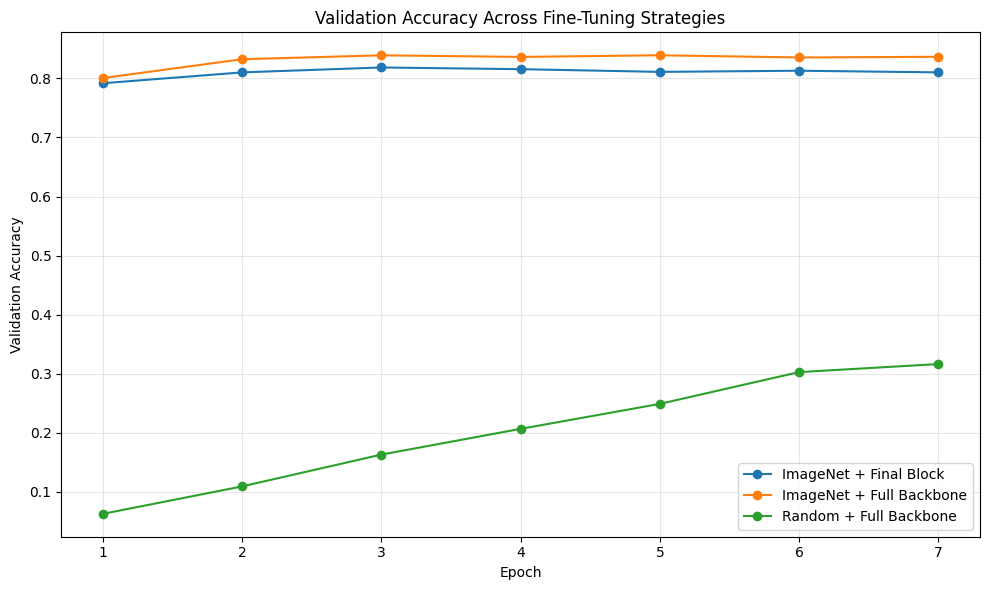

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history_imagenet_final["val_accuracy"],
    marker="o",
    label="ImageNet + Final Block"
)

plt.plot(
    history_imagenet_full["val_accuracy"],
    marker="o",
    label="ImageNet + Full Backbone"
)

plt.plot(
    history_random_full["val_accuracy"],
    marker="o",
    label="Random + Full Backbone"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across Fine-Tuning Strategies")
plt.xticks(range(7), range(1, 8))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


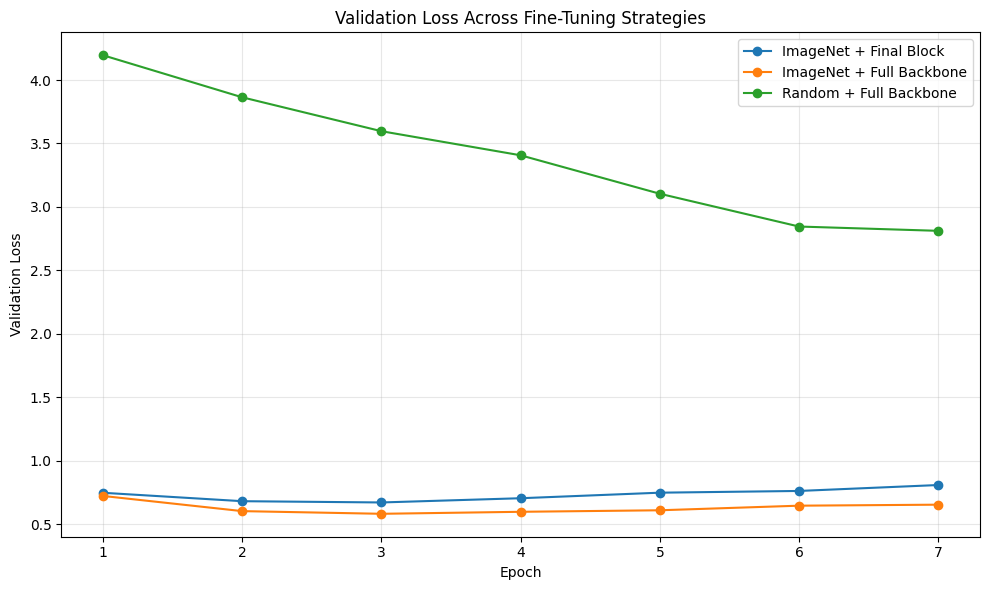

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_imagenet_final["val_loss"],
    marker="o",
    label="ImageNet + Final Block"
)

plt.plot(
    history_imagenet_full["val_loss"],
    marker="o",
    label="ImageNet + Full Backbone"
)

plt.plot(
    history_random_full["val_loss"],
    marker="o",
    label="Random + Full Backbone"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Across Fine-Tuning Strategies")
plt.xticks(range(7), range(1, 8))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization Function

In [37]:
def plot_training_history(history, title):

    epochs = range(1, len(history["train_accuracy"]) + 1)

    plt.figure(figsize=(9, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xticks(epochs)
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## Plotting Training Curves

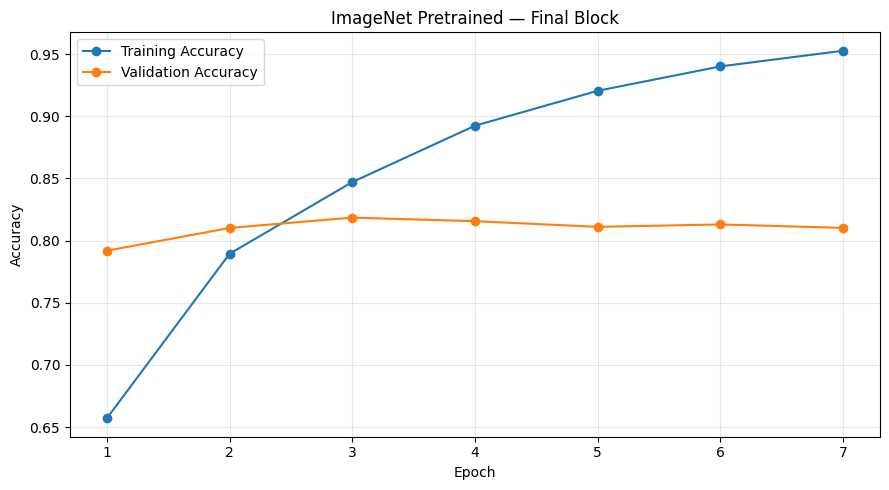

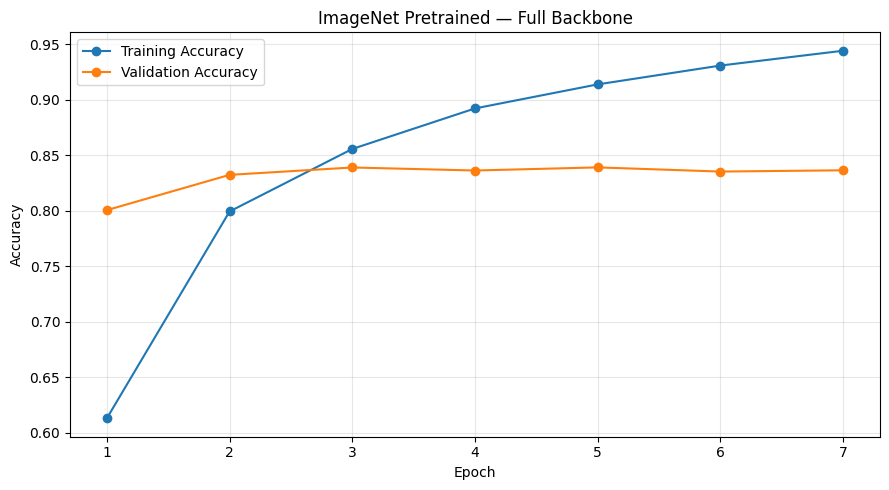

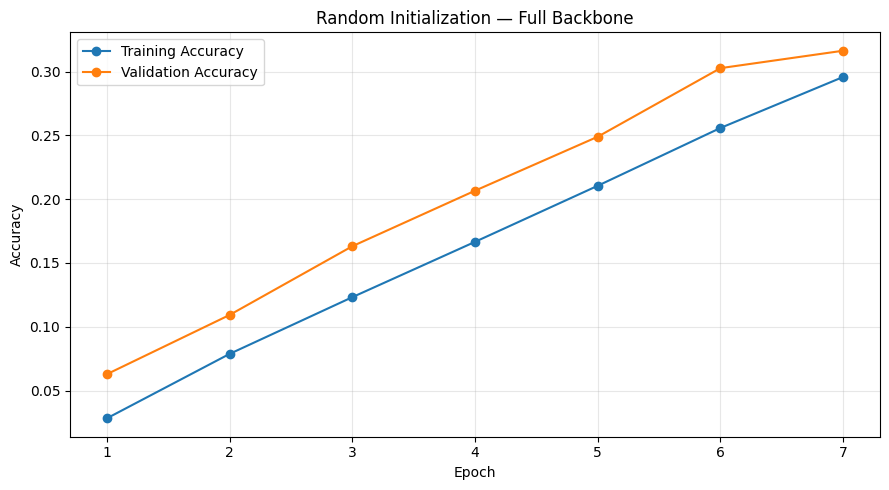

In [38]:
plot_training_history(
    history_imagenet_final,
    "ImageNet Pretrained — Final Block"
)

plot_training_history(
    history_imagenet_full,
    "ImageNet Pretrained — Full Backbone"
)

plot_training_history(
    history_random_full,
    "Random Initialization — Full Backbone"
)


In [39]:
import shutil
from IPython.display import FileLink

results_dir = "/kaggle/working/results"
zip_path = "/kaggle/working/results"

shutil.make_archive(zip_path, "zip", results_dir)

FileLink(zip_path + ".zip")


/kaggle/working/results.zip